# Round 2 — When the Parameters Broke

Same two products as Round 1, a new scored day. The question is therefore not *what are
these products* but:

> **Do Round 1's conclusions still hold?**

Round 1 established four things about this market. This notebook tests each against the
pre-round days and then against the scored day, which is held back until §5.

| | Round 1 conclusion |
|---|---|
| A | ROOT is a deterministic line; its intercept is an exact arithmetic sequence |
| B | ASH mean-reverts, with an empirical half-life around 130 ticks |
| C | Depth imbalance predicts the outer fair, coefficient ≈ 2.5, persisting to 50 ticks |
| D | Interceptable flow ≈ 1,000 lots/day per product across a 13–16 tick spread |

Summary: [`rounds/02/README.md`](../rounds/02/README.md). Specification:
[`rounds/02/answer.md`](../rounds/02/answer.md).

In [1]:
import sys, warnings
sys.path.insert(0, "../tools")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import figures as F
import product_props as pp
import prosperity_review as pr

F.style()
DATA, RND, DAYS = "../data/round2", 2, [-1, 0, 1]
ROOT, ASH = "INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"

px = {d: pp.load(DATA, RND, d)[0] for d in DAYS}
tr = {d: pp.load(DATA, RND, d)[1] for d in DAYS}
scored = pr.load_log("../submissions/round2.log").activities      # held back until §5

def sub(frame, prod):
    return frame[frame["product"] == prod].reset_index(drop=True)

def imbalance(g):
    """Depth imbalance over three levels; NaN on one-sided books."""
    b = g[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0).sum(1)
    a = g[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0).abs().sum(1)
    two = g["bid_price_1"].notna() & g["ask_price_1"].notna()
    return np.where(two & ((b + a) > 0), (b - a) / (b + a).replace(0, np.nan), np.nan)

print("pre-round days loaded:", DAYS)

pre-round days loaded: [-1, 0, 1]


## 1. Conclusion A — ROOT's line

Round 1's three days gave intercepts 10,000 / 11,000 / 12,000 and a scored day of 13,000.
If the sequence is structural, Round 2's pre-round days should continue it.

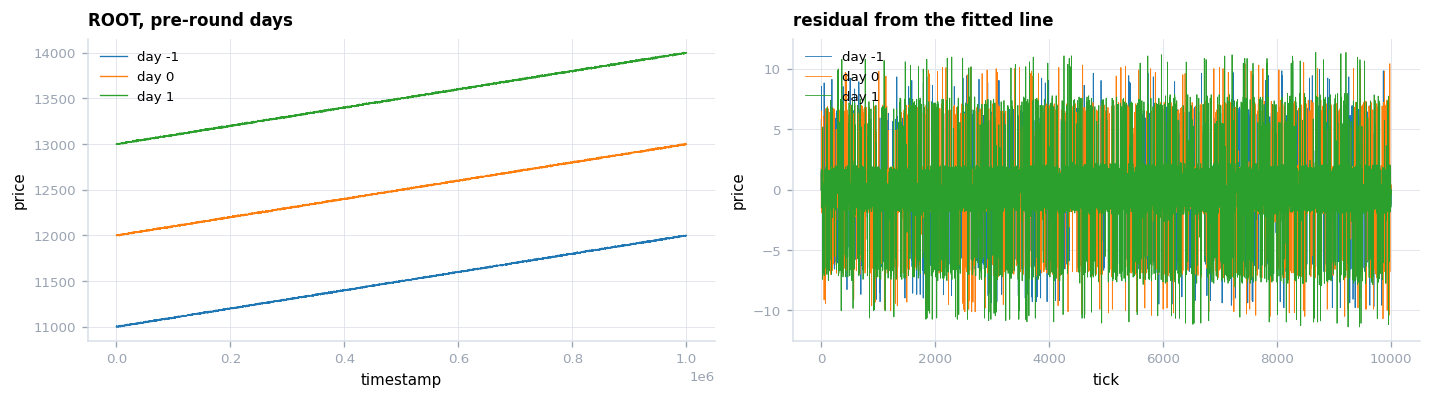

,day,slope,intercept,R2,sd(resid),1st half,2nd half
0,-1,0.001,11000.0,0.999942,2.20,2.18,2.21
1,0,0.001,12000.0,0.999933,2.36,2.35,2.38
2,1,0.001,12999.9,0.999922,2.54,2.50,2.58


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
rows = []
for d in DAYS:
    g = sub(px[d], ROOT); t = g["timestamp"].values; y = pp.best_mid(g)
    b, a = np.polyfit(t, y, 1); res = y - (a + b * t)
    h = len(res) // 2
    rows.append({"day": d, "slope": round(b, 6), "intercept": round(a, 1),
                 "R2": round(1 - res.var() / y.var(), 6),
                 "sd(resid)": round(res.std(), 2),
                 "1st half": round(res[:h].std(), 2), "2nd half": round(res[h:].std(), 2)})
    ax[0].plot(t, y.values, lw=.8, label=f"day {d}")
    ax[1].plot(res.values, lw=.5, label=f"day {d}")
F.finish(ax[0], "ROOT, pre-round days", "timestamp", "price", legend=True)
F.finish(ax[1], "residual from the fitted line", "tick", "price", legend=True)
F.save(fig, "r2_root")
pd.DataFrame(rows)

Slope exactly 0.001, residual flat, intercepts **11,000 / 12,000 / 13,000**.

Together with Round 1 that is **10,000 → 11,000 → 12,000 → 13,000** over four consecutive
days with no error. Extrapolating gives **14,000** for the scored day.

**Conclusion A survives, and it makes a falsifiable prediction.** §5 checks it.

## 2. Conclusion B — ASH's mean reversion

Same estimators as Round 1: regression of the next increment on the deviation, the variance
ratio, and the empirical half-life.

In [3]:
rows = []
for d in DAYS:
    f = pp.largest_level_mid(sub(px[d], ASH)).values
    mu = f.mean()
    ac = [np.corrcoef(f[:-k], f[k:])[0, 1] for k in range(1, 900)]
    rows.append({"day": d, "mean": round(mu, 2), "sd": round(f.std(), 2),
                 "slope": round(np.polyfit(f[:-1] - mu, np.diff(f), 1)[0], 3),
                 "VR(50)": round(pp.vr(f, 50), 3), "VR(200)": round(pp.vr(f, 200), 3),
                 "half-life": next((k for k, v in enumerate(ac, 1) if v < .5), None)})
pd.DataFrame(rows)

,day,mean,sd,slope,VR(50),VR(200),half-life
0,-1,10000.84,4.62,-0.386,0.025,0.009,64
1,0,10001.65,5.78,-0.246,0.026,0.010,196
2,1,10000.25,5.16,-0.314,0.026,0.011,99


Mean near 10,000, slope around −0.3, VR(50) around 0.025, half-life in the tens to low
hundreds. **Indistinguishable from Round 1.** Nothing in the pre-round data warns of what
follows.

## 3. Conclusion C — the depth imbalance signal

Round 1 measured a coefficient near 2.5 against the outer fair, persisting to 50 ticks. The
outer (largest-level) fair is used as the target because inner-order churn moves the touch
and the touch-based size at the same instant, which contaminates the best midpoint.

In [4]:
def imb_fit(g, horizons=(1, 5, 20, 50)):
    o = pp.largest_level_mid(g).values
    x = imbalance(g)
    out = {}
    for h in horizons:
        y = np.r_[o[h:] - o[:-h], [np.nan] * h]
        k = np.isfinite(x) & np.isfinite(y)
        b = np.polyfit(x[k], y[k], 1)[0]
        r = np.corrcoef(x[k], y[k])[0, 1]
        out[f"h={h}"] = (round(b, 2), round(r * np.sqrt(max(k.sum() / h, 2) / max(1 - r * r, 1e-9)), 1))
    return out

rows = []
for prod, nm in [(ASH, "ASH"), (ROOT, "ROOT")]:
    g = pd.concat([sub(px[d], prod) for d in DAYS], ignore_index=True)
    for k, (b, t) in imb_fit(g).items():
        rows.append({"product": nm, "horizon": k, "coefficient": b, "t": t})
pd.DataFrame(rows).pivot(index="product", columns="horizon", values=["coefficient", "t"])

coefficient                       t                 
horizon         h=1  h=20   h=5  h=50   h=1  h=20   h=5 h=50
product                                                     
ASH            2.39  2.32  2.38  2.34  36.9   7.3  16.1  4.1
ROOT           2.88  2.83  2.84  2.84  47.6  10.4  20.8  6.6

**Conclusion C survives on the pre-round days**: coefficient 2.4–2.9, significant out to
50 ticks, matching Round 1.

At this point all four Round 1 conclusions look intact, and a competitor would carry them
forward unchanged. That is what the submission did.

## 4. Conclusion D — flow and spread

In [5]:
pp.flow_check(DATA, RND, DAYS, [ASH, ROOT])

,product,flow/day,median spread,MM ceiling/day
0,ASH_COATED_OSMIUM,1186,16.0,8302
1,INTARIAN_PEPPER_ROOT,807,14.0,4844


Unchanged from Round 1.

---

## 5. The scored day

Everything above used the pre-round days. Now open the scored day.

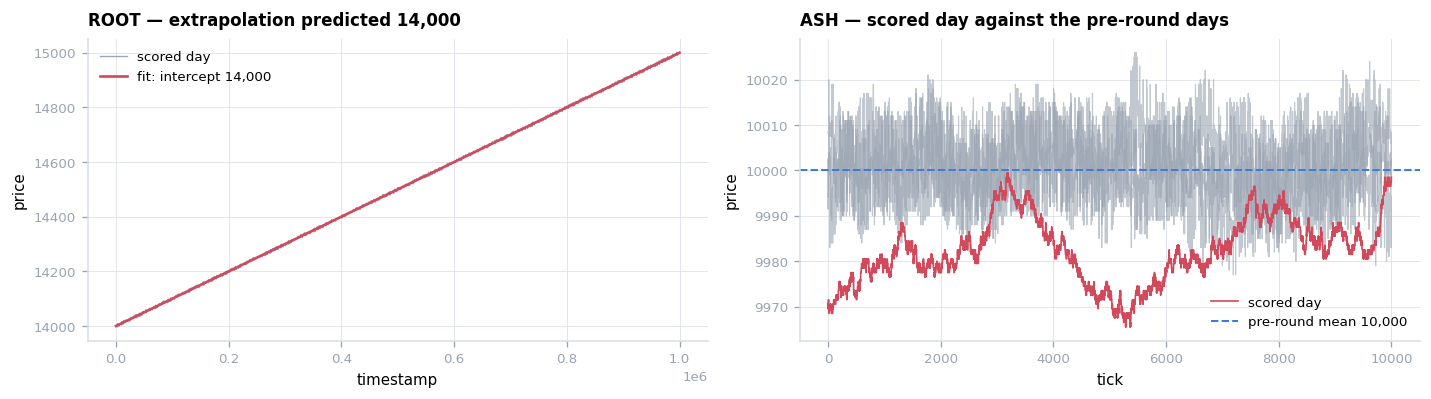

ROOT   slope 0.001000   intercept 14,000.0   R2 0.999980   sd(resid) 1.28
ASH    mean 9982.35   sd 7.08   half-life 625   VR(200) 0.339


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))

g = sub(scored, ROOT); t = g["timestamp"].values; y = pp.best_mid(g)
b, c = np.polyfit(t, y, 1); res = y - (c + b * t)
ax[0].plot(t, y.values, lw=.8, color=F.GREY, label="scored day")
ax[0].plot(t, c + b * t, lw=1.6, color=F.HI, label=f"fit: intercept {c:,.0f}")
F.finish(ax[0], "ROOT — extrapolation predicted 14,000", "timestamp", "price", legend=True)

fa = pp.largest_level_mid(sub(scored, ASH)).values
for d in DAYS:
    ax[1].plot(pp.largest_level_mid(sub(px[d], ASH)).values, lw=.7, color=F.GREY, alpha=.6)
ax[1].plot(fa, lw=1.0, color=F.HI, label="scored day")
ax[1].axhline(10000, color=F.BLUE, ls="--", lw=1.2, label="pre-round mean 10,000")
F.finish(ax[1], "ASH — scored day against the pre-round days", "tick", "price", legend=True)
F.save(fig, "r2_scored")

print(f"ROOT   slope {b:.6f}   intercept {c:,.1f}   R2 {1-res.var()/y.var():.6f}   sd(resid) {res.std():.2f}")
ac = [np.corrcoef(fa[:-k], fa[k:])[0, 1] for k in range(1, 2000)]
print(f"ASH    mean {fa.mean():.2f}   sd {fa.std():.2f}   "
      f"half-life {next((k for k,v in enumerate(ac,1) if v<.5), '>2000')}   VR(200) {pp.vr(fa,200):.3f}")

**Conclusion A held exactly.** The intercept came in at 14,000 with a residual of 0.2 —
*tighter* than any pre-round day.

**Conclusion B did not.** The mean moved 18 points, and the half-life stretched from the
tens-to-low-hundreds to **625 ticks**, with VR(200) rising from ~0.010 to **0.339**.

The level shift is the visible symptom; the change in persistence is what matters. A position
sized for a ~130-tick reversion must now be carried five times as long.

### And conclusion C broke on the same day

The imbalance signal is a completely separate measurement from the mean reversion. If it also
fails, the day is not "ASH's mean moved" — the microstructure itself is different.

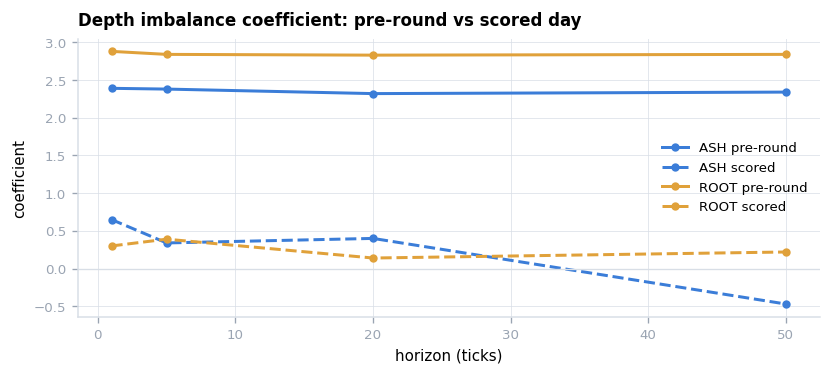

horizon             h=1  h=20   h=5  h=50
product day                              
ASH     pre-round  2.39  2.32  2.38  2.34
        scored     0.65  0.40  0.34 -0.47
ROOT    pre-round  2.88  2.83  2.84  2.84
        scored     0.30  0.14  0.39  0.22

In [7]:
rows = []
for lab, frame, days in [("pre-round", px, DAYS), ("scored", None, None)]:
    for prod, nm in [(ASH, "ASH"), (ROOT, "ROOT")]:
        g = (pd.concat([sub(px[d], prod) for d in days], ignore_index=True)
             if frame is not None else sub(scored, prod))
        for k, (b, t) in imb_fit(g).items():
            rows.append({"day": lab, "product": nm, "horizon": k, "coef": b, "t": t})
tab = pd.DataFrame(rows).pivot(index=["product", "day"], columns="horizon", values="coef")

fig, ax = plt.subplots(figsize=(7, 3.2))
hs = [1, 5, 20, 50]
for (prod, day), row in tab.iterrows():
    ls = "-" if day == "pre-round" else "--"
    col = F.BLUE if prod == "ASH" else F.ACCENT
    ax.plot(hs, [row[f"h={h}"] for h in hs], ls, color=col, lw=1.8, marker="o", ms=4,
            label=f"{prod} {day}")
ax.axhline(0, color=F.GRID, lw=.8)
F.finish(ax, "Depth imbalance coefficient: pre-round vs scored day", "horizon (ticks)",
         "coefficient", legend=True)
F.save(fig, "r2_imbalance_break")
tab

**The signal is gone.** Coefficients fall from 2.4–2.9 to 0.3–0.7, and by 50 ticks ASH's
turns negative.

### Is this an artefact of scored days in general?

The scored day is reconstructed from the submission log rather than supplied as a CSV, so
before concluding anything about the regime, check Round 1's scored day the same way.

In [8]:
r1 = pr.load_log("../submissions/round1.log").activities
rows = []
for lab, frame in [("R1 scored", r1), ("R2 scored", scored)]:
    for prod, nm in [(ASH, "ASH"), (ROOT, "ROOT")]:
        for k, (b, t) in imb_fit(sub(frame, prod)).items():
            rows.append({"round": lab, "product": nm, "horizon": k, "coef": b, "t": t})
pd.DataFrame(rows).pivot(index=["product", "round"], columns="horizon", values=["coef", "t"])

coef                       t                
horizon             h=1  h=20   h=5  h=50   h=1 h=20   h=5 h=50
product round                                                  
ASH     R1 scored  2.37  2.18  2.44  2.36  21.5  4.0   9.6  2.4
        R2 scored  0.65  0.40  0.34 -0.47   2.7  0.1   0.4 -0.1
ROOT    R1 scored  3.20  3.23  3.02  3.07  27.0  6.1  11.5  3.7
        R2 scored  0.30  0.14  0.39  0.22   3.4  0.8   1.2  0.7

**Round 1's scored day retains the signal** — coefficients 2.4 and 3.2, matching its own
pre-round days. The reconstruction is not the cause.

**Round 2's scored day is a genuinely different regime, and two independent signals fail on
it simultaneously.**

## 6. Was the break detectable while it was happening?

Both failures are unobservable in advance. The question is whether they are observable *in
the session*, early enough to act on. The variance ratio can be computed on a rolling window
from the same data the algorithm already receives.

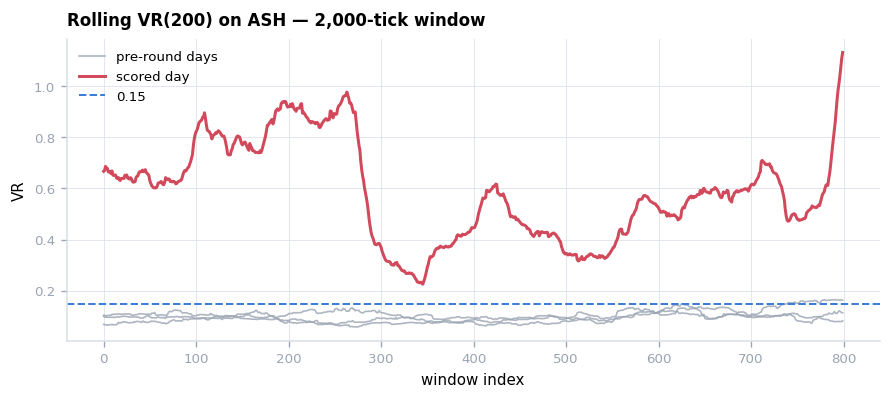

,day,median,90th pct,share above 0.15
0,-1,0.098,0.118,0.0%
1,0,0.090,0.137,7.5%
2,1,0.099,0.129,0.0%
3,scored,0.579,0.869,100.0%


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
rows = []
for d in DAYS:
    v = pp.rolling_vr(pp.largest_level_mid(sub(px[d], ASH)).values)
    ax.plot(v, lw=1.0, color=F.GREY, alpha=.8, label="pre-round days" if d == DAYS[0] else None)
    rows.append({"day": str(d), "median": round(float(np.median(v)), 3),
                 "90th pct": round(float(np.percentile(v, 90)), 3),
                 "share above 0.15": f"{(v > .15).mean():.1%}"})
v = pp.rolling_vr(pp.largest_level_mid(sub(scored, ASH)).values)
ax.plot(v, lw=1.8, color=F.HI, label="scored day")
ax.axhline(.15, color=F.BLUE, ls="--", lw=1.2, label="0.15")
rows.append({"day": "scored", "median": round(float(np.median(v)), 3),
             "90th pct": round(float(np.percentile(v, 90)), 3),
             "share above 0.15": f"{(v > .15).mean():.1%}"})
F.finish(ax, "Rolling VR(200) on ASH — 2,000-tick window", "window index", "VR", legend=True)
F.save(fig, "r2_rolling_vr")
pd.DataFrame(rows)

**Cleanly separable.** The pre-round days sit near 0.09 and exceed 0.15 for under 8% of the
session; the scored day sits at 0.58 and is above 0.15 for **100%** of it. Any threshold in
roughly [0.15, 0.4] separates them.

This is computable from the same book snapshots the algorithm already receives, so a
regime gate is available in principle. §7 records why the implementation is not yet
net-positive.

## 7. What follows for the strategy

**ROOT: reuse Round 1 unchanged**, and seed the intercept from the sequence rather than
estimating it cold. The cold start is where the whole position is built, so it is exactly the
moment the fair price must already be right.

**ASH: the reversion term needs a validity condition.** Not deletion — across the eight days
available (Round 1 and Round 2, pre-round and scored), leaning is right on seven.

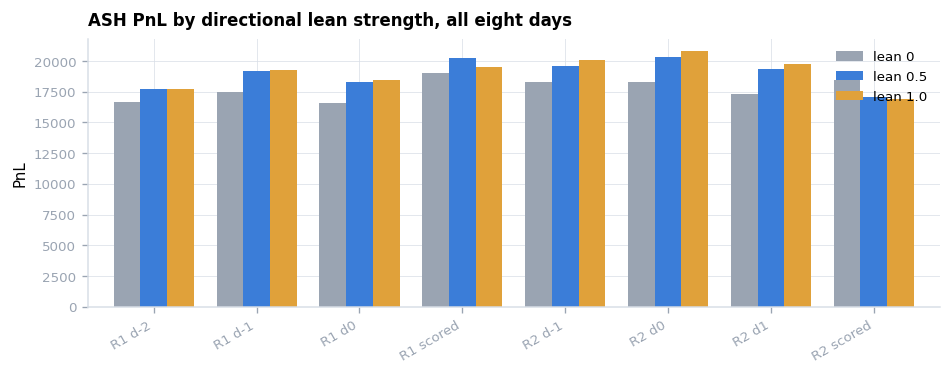

,8-day mean
lean 0,17755.0
lean 0.5,18970.0
lean 1.0,19056.0
mean,NaN


In [10]:
lean = pd.DataFrame({
    "lean 0":    [16623, 17444, 16542, 19050, 18284, 18280, 17323, 18492],
    "lean 0.5":  [17733, 19160, 18298, 20222, 19579, 20331, 19371, 17064],
    "lean 1.0":  [17713, 19233, 18467, 19478, 20112, 20773, 19776, 16899]},
    index=["R1 d-2", "R1 d-1", "R1 d0", "R1 scored",
           "R2 d-1", "R2 d0", "R2 d1", "R2 scored"])
fig, ax = plt.subplots(figsize=(8, 3.2))
lean.plot(kind="bar", ax=ax, color=[F.GREY, F.BLUE, F.ACCENT], width=.78)
F.finish(ax, "ASH PnL by directional lean strength, all eight days", "", "PnL", legend=True)
plt.xticks(rotation=30, ha="right")
F.save(fig, "r2_lean")
lean.assign(**{"mean": lean.mean(axis=1)}).T.assign(**{"8-day mean": lean.mean().round(0)}).iloc[:, -1:]

Seven of eight days favour leaning; only the scored day punishes it. Removing the module
because of one day would cost roughly 1,200 per day on average.

**The correct response is a gate on the reversion term, with pure spread capture as the
fallback** — spread capture does not depend on the reversion assumption, while the
directional term depends on it entirely.

Specification: [`rounds/02/answer.md`](../rounds/02/answer.md).